In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.models import efficientnet_b0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)
        att = self.full_att(self.relu(att1 + att2)).squeeze(2)
        alpha = self.softmax(att)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha


class DecoderWithAttention(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=1280, dropout=0.5):
        super(DecoderWithAttention, self).__init__()

        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)

        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

    def init_hidden_state(self, encoder_out):
        mean_encoder = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder)
        c = self.init_c(mean_encoder)
        return h, c

    def forward(self, encoder_out, captions, lengths):
        pass

Mounted at /content/drive


In [ ]:
save_path = "/content/drive/MyDrive/image_caption_model.pth"

checkpoint = torch.load(save_path, map_location=device)

encoder = nn.Sequential(*list(efficientnet_b0(weights=None).children())[:-2])

decoder = DecoderWithAttention(
    checkpoint['attention_dim'],
    checkpoint['embed_dim'],
    checkpoint['decoder_dim'],
    len(checkpoint['word2idx']),
    checkpoint['encoder_dim']
)

encoder.load_state_dict(checkpoint['encoder_state_dict'])
decoder.load_state_dict(checkpoint['decoder_state_dict'])

encoder = encoder.to(device)
decoder = decoder.to(device)

encoder.eval()
decoder.eval()

word2idx = checkpoint['word2idx']
idx2word = checkpoint['idx2word']

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
def generate_caption_beam(image, beam_size=5, max_length=36):
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        features = encoder(image)

    batch_size = features.size(0)
    encoder_dim = features.size(1)

    features = features.view(batch_size, encoder_dim, -1)
    features = features.permute(0, 2, 1)

    h, c = decoder.init_hidden_state(features)

    start_token = word2idx['<start>']
    end_token = word2idx['<end>']

    sequences = [[ [start_token], 0.0, h, c ]]
    completed = []

    for _ in range(max_length):
        all_candidates = []

        for seq, score, h, c in sequences:

            if seq[-1] == end_token:
                completed.append((seq, score))
                continue

            word = torch.tensor([seq[-1]]).to(device)
            embedding = decoder.embedding(word)

            context, _ = decoder.attention(features, h)

            lstm_input = torch.cat([embedding.squeeze(1), context], dim=1)
            h_new, c_new = decoder.lstm(lstm_input, (h, c))

            output = decoder.fc(h_new)
            log_probs = torch.log_softmax(output, dim=1)

            top_log_probs, top_indices = torch.topk(log_probs, beam_size)

            for i in range(beam_size):
                next_word = top_indices[0][i].item()
                next_score = score + top_log_probs[0][i].item()

                candidate = [seq + [next_word], next_score, h_new, c_new]
                all_candidates.append(candidate)

        sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_size]

        if len(completed) >= beam_size:
            break

    if len(completed) == 0:
        completed = sequences

    best_seq = sorted(completed, key=lambda x: x[1], reverse=True)[0][0]

    caption = [idx2word[idx] for idx in best_seq if idx2word[idx] not in ['<start>', '<end>']]
    return caption

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False, src_lang="eng_Latn")
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

In [ ]:
def translate(text, target_lang):
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(target_lang),
            max_length=100,
            num_beams=5
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)


def to_hindi(text):
    return translate(text, "hin_Deva")


def to_marathi(text):
    return translate(text, "mar_Deva")

Saving Screenshot 2026-04-17 132717.png to Screenshot 2026-04-17 132717 (2).png


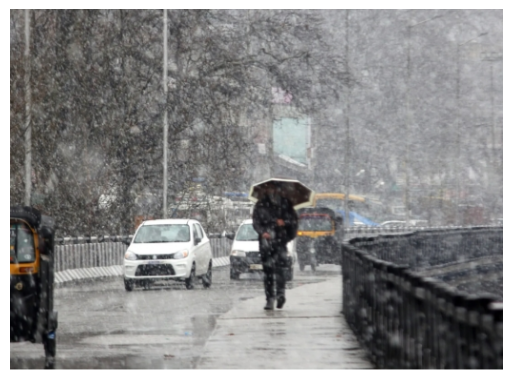


Image: Screenshot 2026-04-17 132717 (2).png
English : a man in a black jacket is walking on a sidewalk in the snow
Hindi   : काले जैकेट में एक आदमी बर्फ में फुटपाथ पर चल रहा है
Marathi : काळा जाकीट घातलेला माणूस बर्फात फुटपाथवर फिरत आहे


In [ ]:
from google.colab import files
uploaded = files.upload()

img_name = list(uploaded.keys())[0]
image = Image.open(img_name).convert("RGB")

plt.imshow(image)
plt.axis('off')
plt.show()

img_tensor = transform(image)

english = " ".join(generate_caption_beam(img_tensor))
hindi = to_hindi(english)
marathi = to_marathi(english)

print("\nImage:", img_name)
print("English :", english)
print("Hindi   :", hindi)
print("Marathi :", marathi)